# CS 171 PS 1
# Due: Friday, April 10, 2026 @ 11:59pm

## Read *all* cells carefully and answer all parts (both text and missing code)

### Enter your information below:

<div style="color: #000000;background-color: #EEEEFF">
    Your Name (submitter): Kaushik Vada <br>
    Your student ID (submitter): 862441522
    
<b>By submitting this notebook, I assert that the work below is my own work, completed for this course.  Except where explicitly cited, none of the portions of this notebook are duplicated from anyone else's work or my own previous work.</b>
</div>


<div class="alert alert-success">
    <font size=+2>Total Problem Set Grading</font> (to be completed by grader)<br>
    Total Points: /20<br>
    Late Days Used on this Assignment: <br>
    Total Late Days Used: <br>
</div>

## Overview

This problem set deals with IMDB review data (from [here](https://ai.stanford.edu/~amaas/data/sentiment/)).  This dataset consists of reviews with either bad (<=4) or good (>=7) ratings.  The cells below load in training and testing data (`trainX`, `trainY` and `testX`, `testY`).  For each point, there are 1000 features, corresponding to the 1000 most common words across all reviews.  Each feature's value is either "none," "once," "couple," "few," "many," or "lots" indicating qualitatively how often the word appears in the review.  These values are encoded as integers from 0 to 5, with 0 indicating "none" and 5 indicating "lots."  These are categorical features.  The corresponding y values are 0 for a "bad" rating and 1 for a "good" rating.

The words that each of these features correspond to are available in the list `featnames`.

In [1]:
## THESE ARE THE ONLY LIBRARIES YOU MAY IMPORT!!
import numpy as np
import matplotlib.pyplot as plt

# below line just to make figures larger
plt.rcParams["figure.figsize"] = (20,10)

In [2]:
def loaddata(fname):
    # ignore how this works! (I'm manipulating a dataset to match the needs for this problem set)
    M = np.loadtxt(fname,dtype=float)
    rs = np.random.RandomState(seed=8675309)
    rs.shuffle(M)
    bi = np.where(M[:,0]==-1)[0]
    gi = np.where(M[:,0]==1)[0]
    M = M[np.hstack((gi,bi[:-4166])),:]
    rs.shuffle(M)
    X = M[:,1:]
    mx = X.max()
    threshs = [0,1,2,5,10,20,mx+1]
    for (i,(t1,t2)) in enumerate(zip(threshs[:-1],threshs[1:])):
        X[(X>=t1) & (X<t2)] = i
    Y = M[:,0]
    Y[Y<=0] = 0 # data is originally +1, -1
    return (X.astype(int),Y.astype(int))

def loadfeatnames(fname):
    with open(fname) as f:
        return(f.read().splitlines())
    

In [3]:
#dataloc = '/usr/local/cs171/'
dataloc = ''
(trainX,trainY) = loaddata(dataloc+'imdbtrain.txt')
(testX,testY) = loaddata(dataloc+'imdbtest.txt')
featnames = loadfeatnames(dataloc+'imdb.vocab')

<div style="color: #000000;background-color: #FFFFEE"><font size=+2>Question 1:</font> <font size=+1>(5 points)</font></div>
<div class="alert alert-success">
    <font size=+1>Grading</font> (to be completed by grader)<br>
    Score: /5<br>
</div>

<div style="color: #000000;background-color: #FFFFEE">
In the cell below, plot a grid of histograms (5 columns, 5 rows)
Each histogram should be the distribution of a different feature (so you will be plotting just the first 25 features).  The histograms should have two sets of bars (each in their own color): ones for examples from class 0 and one for examples from class 1.  You want side-by-side histograms, each with 6 bars (for 12 bars in two colors). Be sure to give a title to each plot with the feature number and the corresponding word.  Use only the training data for these histograms.
    
Hint: look up pyplot's [subplot](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.subplot.html) and [hist](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.hist.html) functions
    
As an example, the histogram in the upper left, corresponding to feature 0, should look like
    
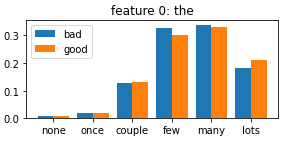
</div>

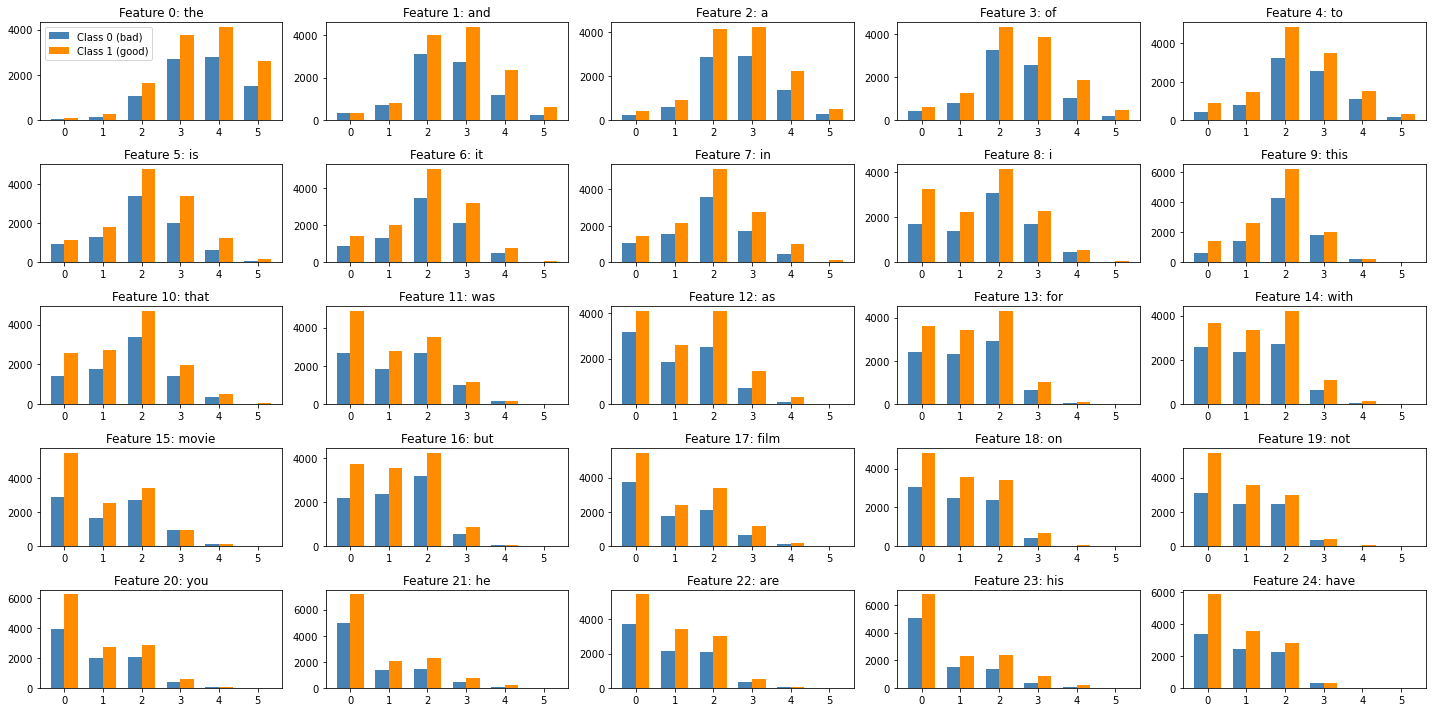

In [4]:
fig, axes = plt.subplots(5, 5, figsize=(20, 10))
featvals = np.arange(6)
width = 0.35

for i in range(25):
    ax = axes[i // 5][i % 5]
    class0 = trainX[trainY == 0, i]
    class1 = trainX[trainY == 1, i]
    counts0 = np.array([(class0 == v).sum() for v in featvals], dtype=float)
    counts1 = np.array([(class1 == v).sum() for v in featvals], dtype=float)
    ax.bar(featvals - width/2, counts0, width, label='Class 0 (bad)', color='steelblue')
    ax.bar(featvals + width/2, counts1, width, label='Class 1 (good)', color='darkorange')
    ax.set_title(f'Feature {i}: {featnames[i]}')
    ax.set_xticks(featvals)
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()

<div style="color: #000000;background-color: #FFFFEE">
    <font size=+2>Question 2:</font> <font size=+1>(5 points)</font>
   </div>
   <div class="alert alert-success">
    <font size=+1>Grading</font> (to be completed by grader)<br>
    Score: /5<br>
</div>

<div style="color: #000000;background-color: #FFFFEE">
    
For the 25 features above, based on the histograms you plotted, which would the most helpful three features for classifying this dataset using naive Bayes?  Which would be the least helpful feature?  <b>WHY?</b>
</div>
    

The three most helpful features from the first 25 are:

1. Feature 17 ("film") - the histograms for bad and good reviews look really different here. Good reviews almost never use the word "film" (big bar at 0), while bad reviews use it a lot more (bigger bars at 1, 2, 3). So Pr(x=0 | y=good) is much higher than Pr(x=0 | y=bad), which gives NB a strong signal.

2. Feature 15 ("movie") - same kind of pattern as "film". The class 0 and class 1 bars have noticeably different heights across the values, so the conditional probability tables for the two classes look different.

3. Feature 11 ("was") - the good reviews tend to use "was" more (bars are taller at values 2-3 for class 1), while bad reviews have more at the lower end. The distributions for the two classes are shaped differently.

The least helpful feature is Feature 13 ("for"). The bars for class 0 and class 1 are almost the same height at every value, meaning Pr(x=v | y=0) is about the same as Pr(x=v | y=1) for all v. If a feature contributes the same factor to both class scores in NB, it doesn't help distinguish the classes at all.

Why this matters: in Naive Bayes we pick the class c that maximizes Pr(y=c) * product of Pr(x_i | y=c). A feature only helps if it contributes a different factor for each class. If the conditional probabilities are the same for both classes, the feature multiplies both scores by the same amount and doesn't change the prediction.

The idea is to look at the Pr(x_j | y) table for each feature (which is what NB builds from the training data), and measure how different the two columns are. If both columns are the same, the feature is useless. If they're very different, the feature is useful.

I measure the goodness of a feature as the sum of absolute differences between the two class-conditional distributions:

    goodness(j) = sum over v of |Pr(x_j=v | y=0) - Pr(x_j=v | y=1)|

This is 0 if the distributions are identical, and gets larger the more they differ.

<div style="color: #000000;background-color: #FFFFEE">
    
Suggest a way to quantify how good a feature is.  Implement it, and list the three best and three worst feature **out of all 1000** features
</div>
    

In [19]:
numfeatvals = 6

# A feature is useful when its Pr(x_j | y) table has different columns for the two classes.
# We measure this as the sum of absolute differences between the two class-conditional distributions.

def feat_goodness(X, Y):
    n = X.shape[1]
    class0 = X[Y == 0]
    class1 = X[Y == 1]
    p0 = np.zeros((n, numfeatvals))
    p1 = np.zeros((n, numfeatvals))
    for v in range(numfeatvals):
        p0[:, v] = (class0 == v).mean(axis=0)  # Pr(x_j=v | y=0)
        p1[:, v] = (class1 == v).mean(axis=0)  # Pr(x_j=v | y=1)
    return np.abs(p0 - p1).sum(axis=1)

scores = feat_goodness(trainX, trainY)
best3_idx  = np.argsort(scores)[::-1][:3]
worst3_idx = np.argsort(scores)[:3]

print("3 best features:")
for i in best3_idx:
    print(f"  Feature {i}: '{featnames[i]}' (score={scores[i]:.4f})")

print("\n3 worst features:")
for i in worst3_idx:
    print(f"  Feature {i}: '{featnames[i]}' (score={scores[i]:.4f})")

3 best features (Pr̂(x|y) columns most different between classes):
  Feature 77: 'bad' (score=0.4652)
  Feature 83: 'great' (score=0.3409)
  Feature 46: '?' (score=0.3199)

3 worst features (Pr̂(x|y) columns most similar between classes):
  Feature 991: 'acted' (score=0.0002)
  Feature 888: 'realize' (score=0.0002)
  Feature 645: 'mostly' (score=0.0004)


<div style="color: #000000;background-color: #FFFFEE">
    <font size=+2>Question 3:</font> <font size=+1>(10 points)</font>
   </div>
   <div class="alert alert-success">
    <font size=+1>Grading</font> (to be completed by grader)<br>
    Score: /10<br>
</div>

<div style="color: #000000;background-color: #FFFFEE">
        
Complete the two functions in the two cells below.

The first trains/learns a naive Bayes classifier.  The second predicts the classes for a set of examples based on the model learned.
    
Hint:  Test your code on the example from the slides in class.  You'll need to generate the data matrix yourself and your own testing examples.
    
Hint 2: You will have to deal with counts that are 0.  Leaving them as zero will result in 0 probabilities that will cause problems.  A standard way to handle this is to add 1 to all counts (this is often called Laplace smoothing).  For frequent feature values, it does not change things much.  Do this separately for each table before normalizing.  For infrequent values, it keeps them away from 0 and admits that they might happen more often than was seen in the data.  This is like pretending there are extra examples that cause the raw counts to increase by 1.  
</div>

In [11]:
def learnnb(X,Y):
    # X is shape (m,n) (m data points, each with n features).  Its elements are integer values from 0 to numfeatvals-1 (inclusive)
    # Y is shape (m,) (m data points).  It has values of either 0 or 1 (class "0" or class "1")
    numfeatvals = X.max().max()+1
    m, n = X.shape
    
    # this function is to return a pair (priorp,condp)
    # where priorp is of shape (2,) and has the prior probability of each of the two classes
    #  and  condp is of shape (n,numfeatvals,2) and has the conditional probabilities for the naive Bayes classifier
    priorp = np.array([(Y == 0).sum(), (Y == 1).sum()], dtype=float) / m

    condp = np.zeros((n, numfeatvals, 2))
    for v in range(numfeatvals):
        condp[:, v, 0] = (X[Y == 0] == v).sum(axis=0)
        condp[:, v, 1] = (X[Y == 1] == v).sum(axis=0)

    condp += 1
    condp /= condp.sum(axis=1, keepdims=True)

    return (priorp, condp)


In [20]:
def prednb(X,model,uselog=True):
    # X is of shape (m,n) (m data points, each with n features).
    # model is the pair (priorp,condp), as returned from learnnb
    # should return something of shape (m,) which is an array of 0s and 1s, indicating
    # the predicted (most probable under NB) class for each of the examples in X
    (priorp,condp) = model
    
    m, n = X.shape

    if uselog:
        log_prior = np.log(priorp)   # shape (2,)
        log_condp = np.log(condp)    # shape (n, numfeatvals, 2)
    else:
        log_prior = priorp
        log_condp = condp

    scores = np.zeros((m, 2))
    feat_idx = np.arange(n)          # shape (n,)

    for c in range(2):
        # For each sample i and feature j, gather log_condp[j, X[i,j], c]
        # feat_idx[np.newaxis, :] broadcasts to (m, n), X is (m, n)
        log_likelihoods = log_condp[feat_idx[np.newaxis, :], X, c] 
        scores[:, c] = log_prior[c] + log_likelihoods.sum(axis=1)

    return scores.argmax(axis=1)

<div style="color: #000000;background-color: #FFFFEE">
The code below trains a naive Bayes classifier and then tests it on the testing examples and reports the error rate.
    
Run the code.  [note, just because your code runs on this example, does not mean it is correct; create a simple example (perhaps a dataset from class or the book) and check it on that.]
</div>


In [13]:
# This code won't run until you at least make the functions above return something
# Do not edit the code below
def errorrate(predY,trueY,uselog=True):
    if len(predY.shape)>1:
        predY = predY[:,0]
    if len(trueY.shape)>1:
        trueY = trueY[:,0]
    return (predY!=trueY).mean()

model = learnnb(trainX,trainY)
predY = prednb(testX,model)
print(errorrate(predY,testY))

0.17889027551118364
